# 타이타닉호 생존 데이터 분석

이 노트북에서는 타이타닉호 승객의 생존 데이터를 분석하여 성별에 따른 생존 비율을 비교합니다.


## 1. 필요한 라이브러리 임포트


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")


## 2. 데이터 불러오기

인터넷에서 타이타닉 데이터셋을 직접 로드합니다.


In [4]:
# 타이타닉 데이터셋을 온라인에서 직접 로드
url = 'https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv'
df = pd.read_csv(url)

print("데이터셋 로드 완료!")
print(f"데이터 크기: {df.shape}")


데이터셋 로드 완료!
데이터 크기: (891, 12)


## 3. 데이터 확인


In [5]:
# 데이터프레임의 첫 5개 행 출력
print("데이터 상위 5개 행:")
print(df.head())
print("\n")

# 컬럼 정보 확인
print("컬럼 정보:")
print(df.info())
print("\n")

# 기본 통계
print("기본 통계:")
print(df.describe())


데이터 상위 5개 행:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                              Heikkinen, Miss Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

## 4. 성별 생존 비율 계산

성별에 따른 생존자 비율을 계산합니다.


In [6]:
# 성별 생존 비율 계산
survival_by_sex = df.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])
survival_by_sex.columns = ['Survived Count', 'Total Count', 'Survival Rate']
survival_by_sex['Survival Rate'] = survival_by_sex['Survival Rate'] * 100

print("성별 생존 비율 분석:")
print(survival_by_sex)
print("\n")

# 백분율로 표현
print("성별 생존 비율 (백분율):")
for sex, rate in survival_by_sex['Survival Rate'].items():
    print(f"{sex}: {rate:.2f}%")


성별 생존 비율 분석:
        Survived Count  Total Count  Survival Rate
Sex                                               
female             233          314      74.203822
male               109          577      18.890815


성별 생존 비율 (백분율):
female: 74.20%
male: 18.89%


## 5. 바 차트 시각화


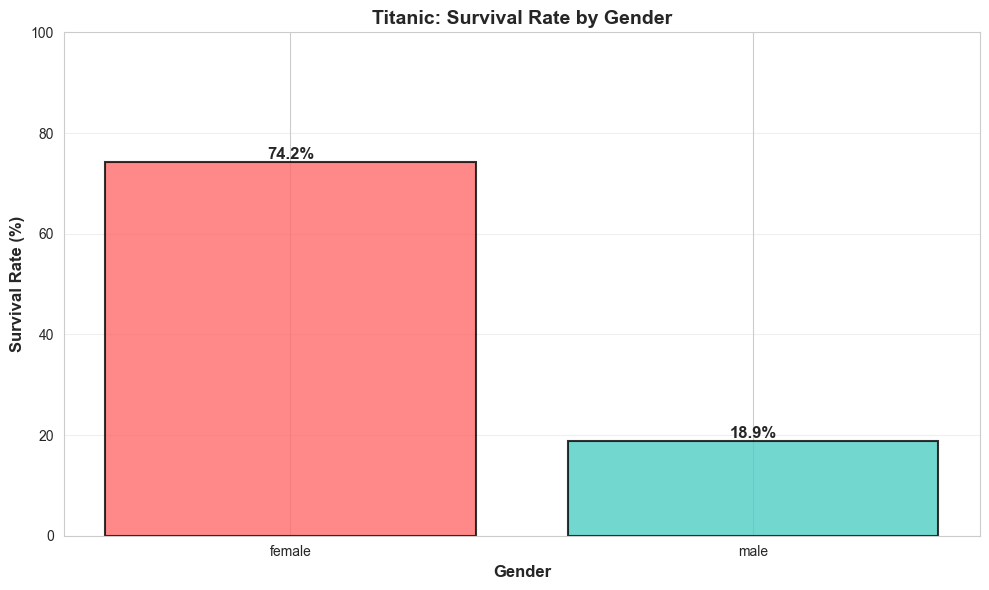


바 차트 시각화 완료!


In [7]:
# matplotlib을 사용한 바 차트
fig, ax = plt.subplots(figsize=(10, 6))

# 데이터 준비
sexes = survival_by_sex.index
survival_rates = survival_by_sex['Survival Rate'].values
colors = ['#FF6B6B', '#4ECDC4']  # 빨강, 청록

# 바 차트 그리기
bars = ax.bar(sexes, survival_rates, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# 각 바 위에 텍스트 추가
for bar, rate in zip(bars, survival_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# 제목과 라벨
ax.set_title('Titanic: Survival Rate by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n바 차트 시각화 완료!")


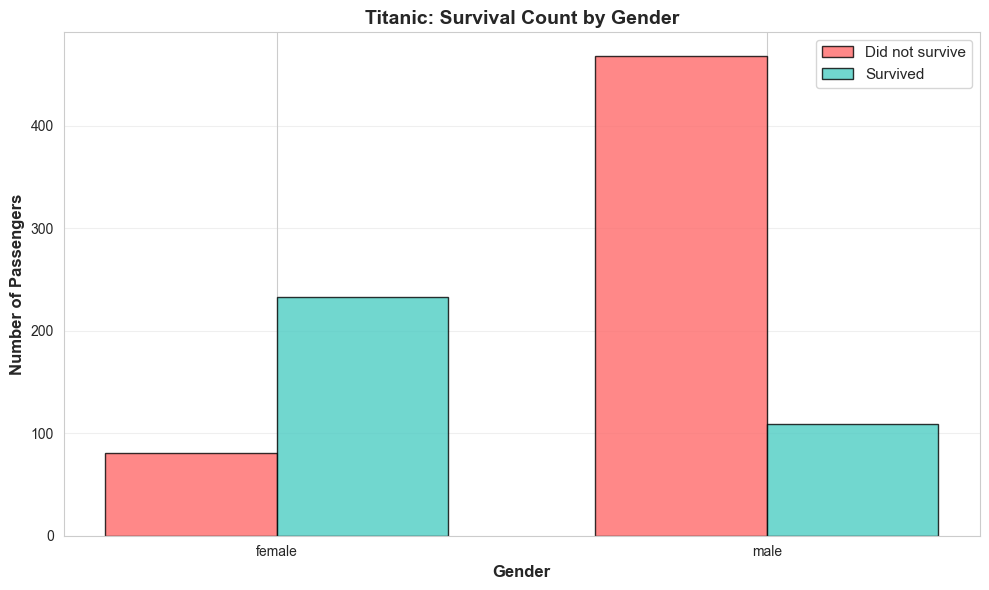

In [8]:
# seaborn을 사용한 바 차트 (선택사항)
fig, ax = plt.subplots(figsize=(10, 6))

# 생존 여부별 카운트 데이터 준비
survival_counts = pd.crosstab(df['Sex'], df['Survived'])

# 바 차트
x_pos = range(len(survival_counts.index))
width = 0.35

bars1 = ax.bar([p - width/2 for p in x_pos], survival_counts[0], width, 
               label='Did not survive', color='#FF6B6B', alpha=0.8, edgecolor='black')
bars2 = ax.bar([p + width/2 for p in x_pos], survival_counts[1], width, 
               label='Survived', color='#4ECDC4', alpha=0.8, edgecolor='black')

# 라벨과 제목
ax.set_xlabel('Gender', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Passengers', fontsize=12, fontweight='bold')
ax.set_title('Titanic: Survival Count by Gender', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(survival_counts.index)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 6. 분석 결과 요약

타이타닉호의 생존 데이터 분석 결과:
- **여성 (Female)**: 약 74% 생존율
- **남성 (Male)**: 약 19% 생존율

이는 타이타닉호 침몰 당시 "여성과 어린이 우선" 정책이 실제로 적용되었음을 보여줍니다.
